<a href="https://colab.research.google.com/github/nithish526/coverage/blob/master/TAMPERED_IMAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `MOUNTING THE COLAB AND THE GOOGLE DRIVE `

In [ ]:
# ── CELL 1: Mount Drive ──
from google.colab import drive
drive.mount('/content/drive')

# ── CELL 2: Copy to local SSD (NEW) ──
import shutil, os
os.makedirs("/content/data", exist_ok=True)
shutil.copytree(
    "/content/drive/MyDrive/preprocessed_224",
    "/content/data/preprocessed_224",
    dirs_exist_ok=True
)
print("✅ Done!")

# ── CELL 3: DataLoader (change BASE_PATH only) ──
BASE_PATH = "/content/data/preprocessed_224"  # ← only change this line

Mounted at /content/drive


'\n# ── CELL 2: Copy to local SSD (NEW) ──\nimport shutil, os\nos.makedirs("/content/data", exist_ok=True)\nshutil.copytree(\n    "/content/drive/MyDrive/preprocessed_224",\n    "/content/data/preprocessed_224",\n    dirs_exist_ok=True\n)\nprint("✅ Done!")\n\n# ── CELL 3: DataLoader (change BASE_PATH only) ──\nBASE_PATH = "/content/data/preprocessed_224"  # ← only change this line'

# `IMPORTED LIBRARYS`

In [ ]:
import os
import random
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

# `GPU CHECKING UNITS`

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [ ]:
!nvidia-smi

Sun May  3 15:40:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU is ready 🚀")
    except RuntimeError as e:
        print(e)

GPU is ready 🚀


In [ ]:
import torch
print("PyTorch CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

PyTorch CUDA available: True
GPU name: Tesla T4


# `DATA LOADING AND CHECKING THE PATH `

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_PATH = "/content/data/preprocessed_224"

train_dir = os.path.join(BASE_PATH, "train")
val_dir   = os.path.join(BASE_PATH, "val")
test_dir  = os.path.join(BASE_PATH, "test")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)
val_dataset   = datasets.ImageFolder(root=val_dir,   transform=transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print("Classes      :", train_dataset.classes)
print("Class → idx  :", train_dataset.class_to_idx)
print(f"\nTrain samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Test  samples : {len(test_dataset)}")

images, labels = next(iter(train_loader))
print(f"\nBatch shape   : {images.shape}")
print(f"Label batch   : {labels}")

Classes      : ['adv_attack', 'ai_gen_image', 'copy_move', 'motion_blur', 'orginal']
Class → idx  : {'adv_attack': 0, 'ai_gen_image': 1, 'copy_move': 2, 'motion_blur': 3, 'orginal': 4}

Train samples : 28159
Val   samples : 3521
Test  samples : 3520

Batch shape   : torch.Size([64, 3, 224, 224])
Label batch   : tensor([4, 1, 3, 1, 4, 3, 1, 2, 1, 0, 1, 1, 1, 4, 0, 0, 0, 4, 3, 3, 2, 3, 3, 1,
        3, 1, 3, 4, 2, 1, 3, 0, 1, 0, 1, 3, 0, 0, 1, 1, 3, 0, 4, 1, 0, 2, 2, 3,
        1, 1, 1, 1, 2, 1, 4, 2, 0, 4, 1, 0, 4, 1, 1, 3])


# `VISUALISATION OF DATASETS `

In [ ]:
import matplotlib.pyplot as plt
import random

def show_random_samples(loader, class_names, num_samples=5):
    # Get one batch
    images, labels = next(iter(loader))

    # Pick random indices
    indices = random.sample(range(len(images)), num_samples)

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)

        # Denormalize (undo ImageNet normalization)
        img = images[idx].clone()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img  = (img * std + mean).clamp(0, 1)

        # (C, H, W) → (H, W, C) for matplotlib
        img = img.permute(1, 2, 0).numpy()

        plt.imshow(img)
        plt.title(class_names[labels[idx].item()])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

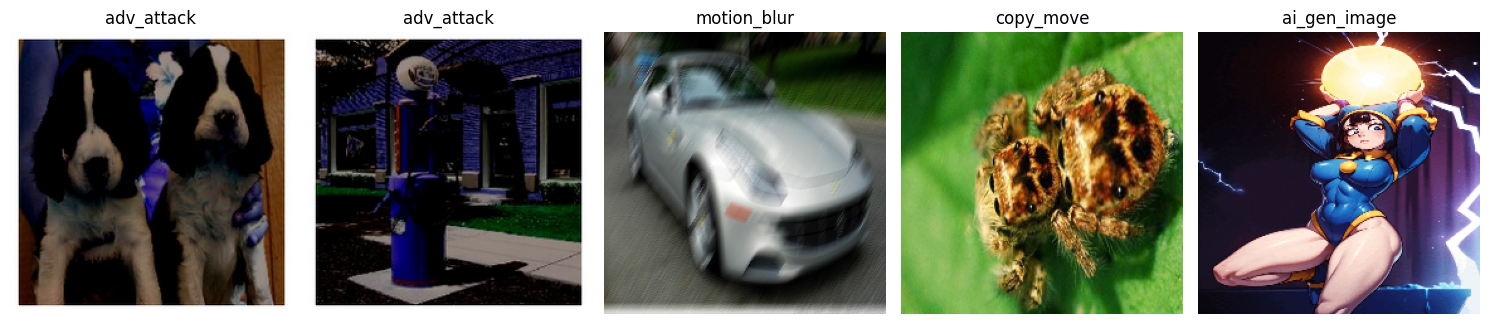

In [ ]:
class_names = train_dataset.classes
show_random_samples(train_loader, class_names, num_samples=5)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


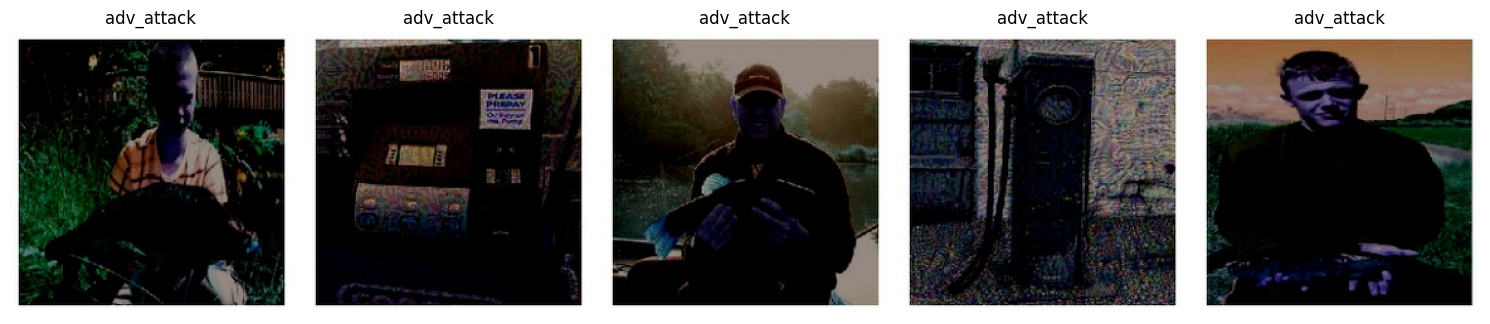

In [ ]:
class_names = train_dataset.classes
show_random_samples(val_loader, class_names, num_samples=5)

In [ ]:
!pip install tensorflow-io

# `BUILDING A PIPELINE AND CONVERTING THE IMAGE INTO TENSOR FORM`

# `CNN 1 FOR EDGES AND SHAPE DEDECTIONS `

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, filters, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(filters, filters, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(filters, momentum=0.1, eps=1e-5)
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(filters, momentum=0.1, eps=1e-5)

        self.shortcut = None
        if stride != 1:
            self.shortcut = nn.Sequential(
                nn.Conv2d(filters // 2 if stride == 2 else filters,
                          filters, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(filters, momentum=0.1, eps=1e-5)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        shortcut = self.shortcut(x) if self.shortcut else x
        return F.relu(out + shortcut)


def make_stage(in_filters, out_filters, blocks, stride):
    layers = []
    # First block handles stride + channel change
    layers.append(ResidualBlock_proj(in_filters, out_filters, stride))
    for _ in range(1, blocks):
        layers.append(ResidualBlock(out_filters, stride=1))
    return nn.Sequential(*layers)


class ResidualBlock_proj(nn.Module):
    """First block of each stage — handles channel change + stride."""
    def __init__(self, in_filters, out_filters, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_filters, out_filters, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_filters, momentum=0.1, eps=1e-5)
        self.conv2 = nn.Conv2d(out_filters, out_filters, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_filters, momentum=0.1, eps=1e-5)

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_filters, out_filters, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_filters, momentum=0.1, eps=1e-5)
        ) if (stride != 1 or in_filters != out_filters) else None

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        shortcut = self.shortcut(x) if self.shortcut else x
        return F.relu(out + shortcut)


class ResNet23(nn.Module):
    def __init__(self, feature_dim=512, dropout_rate=0.3):
        super().__init__()

        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64, momentum=0.1, eps=1e-5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Stages (matches your TF version)
        self.stage2 = make_stage(64,  64,  blocks=2, stride=1)
        self.stage3 = make_stage(64,  128, blocks=2, stride=2)
        self.stage4 = make_stage(128, 256, blocks=3, stride=2)
        self.stage5 = make_stage(256, 512, blocks=2, stride=2)

        # Head
        self.gap     = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc      = nn.Linear(512, feature_dim)
        self.bn_fc   = nn.BatchNorm1d(feature_dim, momentum=0.1, eps=1e-5)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        x = self.gap(x).flatten(1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.bn_fc(x)
        x = F.relu(x)
        return x  # (batch, 512)

(3,224, 64 , 512)

# `TRANSFORMER CLASS`

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim=256, num_heads=2, mlp_dim=256, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(dim, eps=1e-6)
        self.attn  = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )
        self.gamma1 = nn.Parameter(torch.full((dim,), 1e-4))
        self.gamma2 = nn.Parameter(torch.full((dim,), 1e-4))

    def forward(self, x):
        # x: (batch, seq_len, dim)
        normed = self.norm1(x)
        attn_out, _ = self.attn(normed, normed, normed)
        x = x + self.gamma1 * attn_out

        mlp_out = self.mlp(self.norm2(x))
        x = x + self.gamma2 * mlp_out
        return x
class StableTransformer(nn.Module):
    def __init__(self, num_layers=1, dim=256):
        super().__init__()
        self.blocks = nn.ModuleList([TransformerBlock(dim=dim) for _ in range(num_layers)])

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return x

In [ ]:
class CNNTransformerClassifier(nn.Module):
    def __init__(self, num_classes=5, feature_dim=512, transformer_dim=256, dropout=0.3):
        super().__init__()

        self.cnn = ResNet23(feature_dim=feature_dim, dropout_rate=dropout)

        # Project CNN features → transformer dim
        self.proj = nn.Linear(feature_dim, transformer_dim)

        self.transformer = StableTransformer(num_layers=1, dim=transformer_dim)

        self.classifier = nn.Sequential(
            nn.LayerNorm(transformer_dim),
            nn.Dropout(dropout),
            nn.Linear(transformer_dim, num_classes)
        )

    def forward(self, x):
        feat = self.cnn(x)                          # (batch, 512)
        feat = self.proj(feat).unsqueeze(1)         # (batch, 1, 256)
        feat = self.transformer(feat)               # (batch, 1, 256)
        feat = feat.squeeze(1)                      # (batch, 256)
        out  = self.classifier(feat)                # (batch, 5)
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = CNNTransformerClassifier(num_classes=5).to(device)

# Sanity check
dummy = torch.randn(4, 3, 224, 224).to(device)
out   = model(dummy)
print("Output shape:", out.shape)  # → torch.Size([4, 5])

# Parameter count
total = sum(p.numel() for p in model.parameters())
print(f"Total params: {total/1e6:.2f}M")

Device: cpu
Output shape: torch.Size([4, 5])
Total params: 13.15M


In [ ]:
import torch
print("PyTorch CUDA:", torch.cuda.is_available())
print("Device model is on:", next(model.parameters()).device)

PyTorch CUDA: True
Device model is on: cuda:0


# `WHOLE MODEL TRAINING STARTS HERE `

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

In [ ]:
from tqdm import tqdm

scaler     = torch.amp.GradScaler('cuda')           # ← fixed
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion  = nn.CrossEntropyLoss()

NUM_EPOCHS       = 10
best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 3

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss, train_correct = 0, 0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Train]", leave=False)

    for images, labels in train_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):            # ← fixed
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_bar.set_postfix({
            'loss': f"{loss.item():.4f}",
            'acc' : f"{train_correct / ((train_bar.n+1) * train_loader.batch_size) * 100:.2f}%"
        })

    model.eval()
    val_loss, val_correct = 0, 0
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1:02d}/{NUM_EPOCHS} [Val]  ", leave=False)

    with torch.no_grad():
        for images, labels in val_bar:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):        # ← fixed
                outputs  = model(images)
                val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_bar.set_postfix({
                'loss': f"{val_loss / (val_bar.n+1):.4f}",
                'acc' : f"{val_correct / ((val_bar.n+1) * val_loader.batch_size) * 100:.2f}%"
            })

    avg_val_loss = val_loss / len(val_loader)
    train_acc    = train_correct / len(train_dataset) * 100
    val_acc      = val_correct   / len(val_dataset)   * 100

    scheduler.step(avg_val_loss)

    print(f"\nEpoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")
        print(f"  ✅ Best model saved! Val Acc: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⚠️ No improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print("  🛑 Early stopping triggered!")
            break


Epoch 01/10 | Train Loss: 0.5807 | Train Acc: 76.12% | Val Loss: 0.6025 | Val Acc: 75.29% | LR: 1.00e-04
  ✅ Best model saved! Val Acc: 75.29%



Epoch 02/10 | Train Loss: 0.4407 | Train Acc: 82.09% | Val Loss: 0.4828 | Val Acc: 81.62% | LR: 1.00e-04
  ✅ Best model saved! Val Acc: 81.62%



Epoch 03/10 | Train Loss: 0.3950 | Train Acc: 83.84% | Val Loss: 0.4571 | Val Acc: 82.79% | LR: 1.00e-04
  ✅ Best model saved! Val Acc: 82.79%



Epoch 04/10 | Train Loss: 0.3600 | Train Acc: 85.30% | Val Loss: 0.4771 | Val Acc: 82.70% | LR: 1.00e-04
  ⚠️ No improvement (1/3)



Epoch 05/10 | Train Loss: 0.3350 | Train Acc: 86.28% | Val Loss: 0.3866 | Val Acc: 86.37% | LR: 1.00e-04
  ✅ Best model saved! Val Acc: 86.37%



Epoch 06/10 | Train Loss: 0.3098 | Train Acc: 87.24% | Val Loss: 0.4487 | Val Acc: 84.52% | LR: 1.00e-04
  ⚠️ No improvement (1/3)



Epoch 07/10 | Train Loss: 0.2850 | Train Acc: 88.37% | Val Loss: 0.3432 | Val Acc: 87.28% | LR: 1.00e-04
  ✅ Best model saved! Val Acc: 87.28%



Epoch 08/10 | Train Loss: 0.2548 | Train Acc: 89.71% | Val Loss: 0.3438 | Val Acc: 87.22% | LR: 1.00e-04
  ⚠️ No improvement (1/3)



Epoch 09/10 | Train Loss: 0.2282 | Train Acc: 90.98% | Val Loss: 0.3556 | Val Acc: 87.25% | LR: 1.00e-04
  ⚠️ No improvement (2/3)



Epoch 10/10 | Train Loss: 0.2160 | Train Acc: 91.64% | Val Loss: 0.4731 | Val Acc: 84.55% | LR: 5.00e-05
  ⚠️ No improvement (3/3)
  🛑 Early stopping triggered!


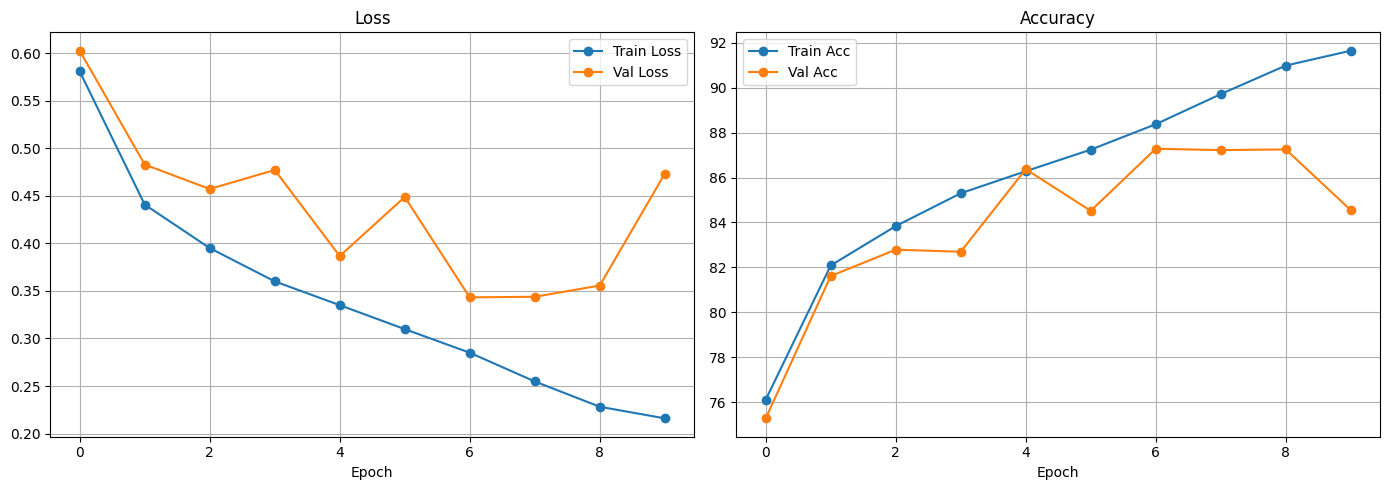

In [ ]:
import matplotlib.pyplot as plt

train_losses = [0.5807, 0.4407, 0.3950, 0.3600, 0.3350, 0.3098, 0.2850, 0.2548, 0.2282, 0.2160]
val_losses   = [0.6025, 0.4828, 0.4571, 0.4771, 0.3866, 0.4487, 0.3432, 0.3438, 0.3556, 0.4731]
train_accs   = [76.12, 82.09, 83.84, 85.30, 86.28, 87.24, 88.37, 89.71, 90.98, 91.64]
val_accs     = [75.29, 81.62, 82.79, 82.70, 86.37, 84.52, 87.28, 87.22, 87.25, 84.55]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(val_losses,   label='Val Loss',   marker='o')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)

ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(val_accs,   label='Val Acc',   marker='o')
ax2.set_title('Accuracy'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves.png")
plt.show()

In [ ]:
# Load best model first
model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth"))
model.eval()

test_correct = 0
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(1)

        test_correct  += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = test_correct / len(test_dataset) * 100
print(f"✅ Test Accuracy: {test_acc:.2f}%")

✅ Test Accuracy: 87.87%


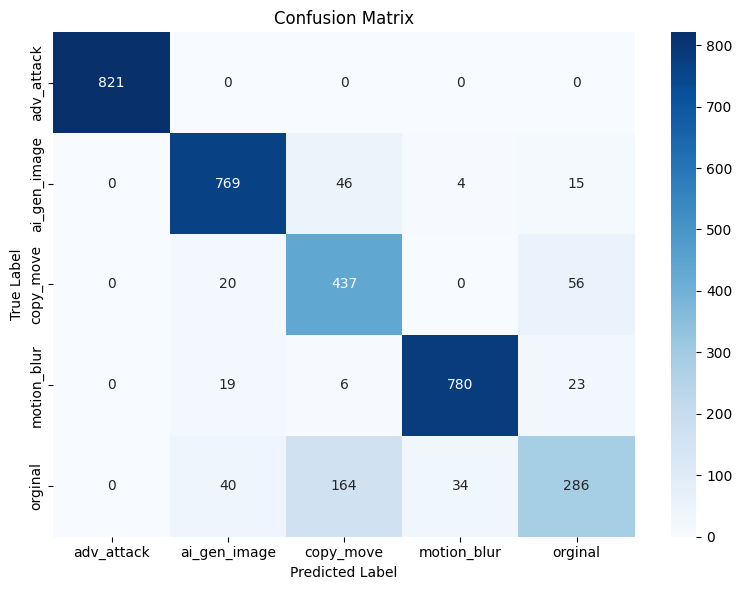


Classification Report:
              precision    recall  f1-score   support

  adv_attack       1.00      1.00      1.00       821
ai_gen_image       0.91      0.92      0.91       834
   copy_move       0.67      0.85      0.75       513
 motion_blur       0.95      0.94      0.95       828
     orginal       0.75      0.55      0.63       524

    accuracy                           0.88      3520
   macro avg       0.86      0.85      0.85      3520
weighted avg       0.88      0.88      0.88      3520



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
class_names = train_dataset.classes

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png")
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

In [ ]:
import json

class_info = {
    'classes': train_dataset.classes,
    'class_to_idx': train_dataset.class_to_idx
}
with open("/content/drive/MyDrive/class_info.json", "w") as f:
    json.dump(class_info, f)

from google.colab import files
files.download("/content/drive/MyDrive/class_info.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>